In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ev_cleaned = pd.read_csv("../data/ev_population_cleaned.csv")
ev_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   postal_code         581 non-null    float64
 1   ev_count            581 non-null    int64  
 2   avg_electric_range  581 non-null    float64
 3   bev_ratio           581 non-null    float64
 4   avg_base_msrp       581 non-null    float64
 5   lat                 581 non-null    float64
 6   lon                 581 non-null    float64
 7   demand_level        581 non-null    object 
 8   log_ev_count        581 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 41.0+ KB


In [3]:
ev_cleaned.head()

,postal_code,ev_count,avg_electric_range,bev_ratio,avg_base_msrp,lat,lon,demand_level,log_ev_count
0,83854.0,2,-1.414878,1.316834,-0.193959,47.71189,-116.94810,Low,1.098612
1,83858.0,1,-0.626364,-3.750638,-0.193959,47.81137,-116.89644,Low,0.693147
2,83876.0,1,-1.414878,1.316834,-0.193959,47.40077,-116.91895,Low,0.693147
3,97006.0,1,-1.414878,1.316834,-0.193959,45.53043,-122.88429,Low,0.693147
4,97027.0,1,-0.990294,-3.750638,11.940784,45.38059,-122.59479,Low,0.693147


## Modeling

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

### Defining the Target and Features

In [5]:
X = ev_cleaned[["avg_electric_range", "bev_ratio", "avg_base_msrp", "lat", "lon"]]
y = ev_cleaned["log_ev_count"]

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline Model: Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R^2: ", round(r2_score(y_test, y_pred_lr), 4))
print("\n RMSE: ", round(mean_squared_error(y_test, y_pred_lr), 2))

Linear Regression R^2:  0.0818

 RMSE:  4.88


### Regularized Models: Ridge & Lasso

In [7]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
print("Ridge R^2: ", round(ridge.score(X_test, y_test), 4))

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
print("Lasso R^2: ", round(lasso.score(X_test, y_test), 4))

Ridge R^2:  0.0818
Lasso R^2:  0.0911


### Tree-Based Model: Random Forest Regressor

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R^2: ", round(r2_score(y_test, y_pred_rf), 4))
print("\n RMSE: ", round(mean_squared_error(y_test, y_pred_rf), 2))

Random Forest R^2:  0.8989

 RMSE:  0.54


### Advanced Model: XGBoost

In [9]:
#pip install xgboost

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost R^2: ", round(r2_score(y_test, y_pred_xgb), 4))
print("\n RMSE: ", round(mean_squared_error(y_test, y_pred_xgb), 2))

XGBoost R^2:  0.8908

 RMSE:  0.58


## Compare Model Peformance

In [11]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost'],
    'R^2': [
        round(r2_score(y_test, y_pred_lr), 4),
        round(ridge.score(X_test, y_test), 4),
        round(lasso.score(X_test, y_test), 4),
        round(r2_score(y_test, y_pred_rf), 4),
        round(r2_score(y_test, y_pred_xgb), 4)
    ],
    'RMSE': [
        round(mean_squared_error(y_test, y_pred_lr), 2),
        round(mean_squared_error(y_test, ridge.predict(X_test)), 2),
        round(mean_squared_error(y_test, lasso.predict(X_test)), 2),
        round(mean_squared_error(y_test, y_pred_rf), 2),
        round(mean_squared_error(y_test, y_pred_xgb), 2)
    ]
})

In [12]:
print(results)

           Model     R^2  RMSE
0         Linear  0.0818  4.88
1          Ridge  0.0818  4.88
2          Lasso  0.0911  4.83
3  Random Forest  0.8989  0.54
4        XGBoost  0.8908  0.58


## Feature Importance + SHAP Explainability

In [13]:
# Random Forest Regressor Feature Importances
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_names = X_train.columns

### Feature Importance for Random Forest

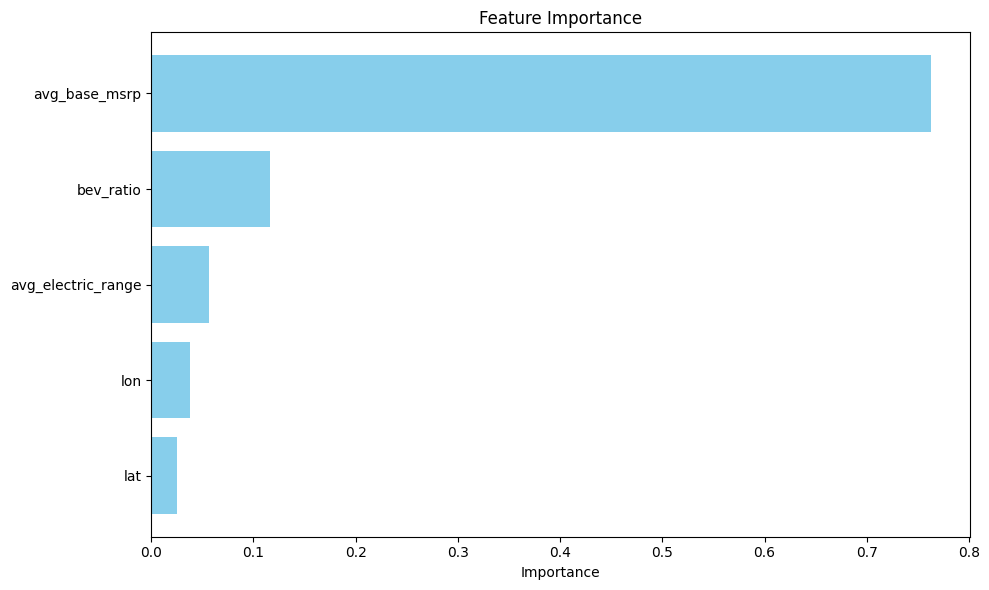

In [14]:
# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot using matplotlib
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### SHAP (SHapley Additive exPlanations)

In [15]:
#pip install shap

In [16]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)

# Get SHAP values for a sample
shap_values = explainer.shap_values(X_train)

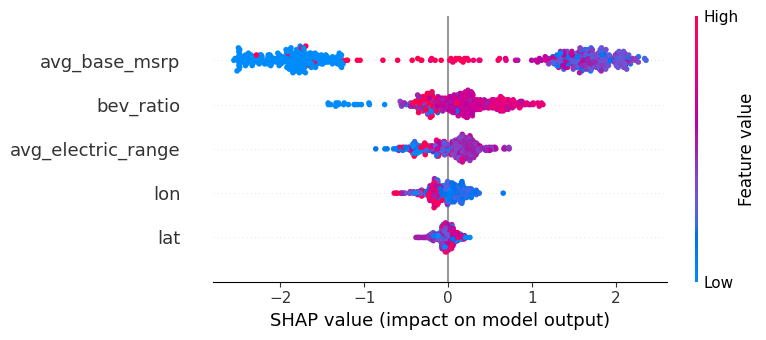

In [19]:
# Summary plot
shap.summary_plot(shap_values, X_train)

# Conclusion

As part of this project, I set out to predict the number of Electric Vehicles (EVs) per postal code using regional and vehicle characteristics. I experimented with both basic and advanced regression models, and found that **Random Forest** and **XGBoost** performed the best, achieving an R^2 of ~0.89 and low RMSE values which is a strong indication that the models captured meaningful patterns in the data.

To better understand what influenced the predictions, I explored **feature importance** and used **SHAP** for interpretability. These analyses showed that:
1. **Average base MSRP** had the highest impact on EV density predictions,
2. Followed by the **BEV ratio** and **average electric range**.

This process helped me go beyond just building a model but also gave me a **clearer** understanding of the factors that may shape EV adoption across regions.